In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 49.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 104.1 MB/s eta 0:00:0000:0100:01


In [2]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pennylane as qml


In [3]:
class ClassicalCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ClassicalCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Input: 3x32x32 → 32x32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # → 64x32x32
        self.pool = nn.MaxPool2d(2, 2)                           # → 64x16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # → 128x16x16
        self.pool2 = nn.MaxPool2d(2, 2)                            # → 128x8x8

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool2(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
# Define quantum circuit for hybrid model


class HybridQuantumHiddenLayerModel(nn.Module):

    def __init__(self, n_qubits):
        super(HybridQuantumHiddenLayerModel, self).__init__()
        self.n_qubits = n_qubits
        weight_shapes = {"weights": (2, n_qubits, 3)}
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.templates.AngleEmbedding(inputs, wires=range(self.n_qubits))
            qml.templates.StronglyEntanglingLayers(weights, wires=range(self.n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.qprep1 = nn.Linear(64, self.n_qubits)
        self.qprep2 = nn.Linear(64, self.n_qubits)

        self.qlayer1 = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.qlayer2 = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        self.out = nn.Linear(self.n_qubits * 2, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))

        x1 = self.qprep1(x)
        x2 = self.qprep2(x)

        q1 = self.qlayer1(x1)
        q2 = self.qlayer2(x2)

        x = torch.cat([q1, q2], dim=1)
        x = self.out(x)
        return x

In [5]:

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'epoch_time': []
    }
    model.to(device)

    for epoch in range(epochs):
        model.train()
        start_time = time.time()

        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        epoch_duration = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_duration)

        print(f"Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, Time={epoch_duration:.2f}s")

    return history

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import time
import torch.nn.functional as F


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in data_loader:
            # Ensure images and labels are Tensors before moving to device
            images = torch.as_tensor(images)
            labels = torch.as_tensor(labels)
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

def test_metrics(model, test_loader, device, class_names, show_plot=True):
  model.eval()
  all_preds = []
  all_labels = []
  all_probs = []

  start_time = time.time()
  with torch.no_grad():
    for images, labels in test_loader:
      images = torch.as_tensor(images).to(device)
      labels = torch.as_tensor(labels).to(device)
      outputs = model(images)
      probs = F.softmax(outputs, dim=1)
      preds = torch.argmax(probs, dim=1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
      all_probs.extend(probs.cpu().numpy())

    inference_time = (time.time() - start_time) / len(test_loader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if show_plot:
        conf_mat = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_mat, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    return acc, precision, recall, f1, inference_time, all_labels, all_probs

def plot_roc_curve(y_true, y_score, class_names, model_name):
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_onehot = np.zeros_like(y_score)
    y_onehot[np.arange(len(y_true)), y_true] = 1

    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_onehot[:, i], y_score[:, i])
        auc = roc_auc_score(y_onehot[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()




def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def summary_table(model_name, acc, prec, rec, f1, inf_time, param_count):
    data = {
        'Model': [model_name],
        'Accuracy': [f"{acc:.4f}"],
        'Precision': [f"{prec:.4f}"],
        'Recall': [f"{rec:.4f}"],
        'F1-Score': [f"{f1:.4f}"],
        'Inference Time (s/img)': [f"{inf_time:.6f}"],
        'Param Count': [param_count]
    }
    df = pd.DataFrame(data)
    print(df.to_markdown(index=False))
    return df

def get_loaders(batch_size=32):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    target_classes = [0, 1, 2, 3, 8]  # Airplane, Automobile, Bird, Cat, Ship
    max_per_class = 2500
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'ship']

    train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

    train_dataset = filter_dataset(train_dataset)
    test_dataset = filter_dataset(test_dataset)

    # Split training data into train and validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, class_names

def filter_dataset(dataset):
    target_classes = [0, 1, 2, 3, 8]  # Airplane, Automobile, Bird, Cat, Ship
    max_per_class = 2500
    targets = np.array(dataset.targets)
    data = dataset.data
    filtered_data = []
    filtered_targets = []
    original_to_new_idx = {original: new for new, original in enumerate(target_classes)}

    for cls in target_classes:
        idx = np.where(targets == cls)[0][:max_per_class]
        filtered_data.append(data[idx])
        filtered_targets.extend([original_to_new_idx[cls]] * len(idx))

    dataset.data = np.concatenate(filtered_data)
    dataset.targets = filtered_targets
    return dataset


In [18]:
def load_model_and_test(model_class, model_path, device, test_loader, class_names, model_name, plot_roc=True):
    model = model_class.to(device)

    if model_path is not None:
        model.load_state_dict(torch.load(model_path, map_location=device))

    model.eval()

    acc, precision, recall, f1, inf_time, labels, probs = test_metrics(
        model, test_loader, device, class_names
    )
    params = count_parameters(model)
    summary_table(model_name, acc, precision, recall, f1, inf_time, params)

    if plot_roc:
        plot_roc_curve(labels, probs, class_names, model_name)

    return model


## TRaining

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
from sklearn.metrics import accuracy_score
from collections import OrderedDict

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=24):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'epoch_time': []
    }

    model.to(device)

    for epoch in range(epochs):
        model.train()
        start_time = time.time()

        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # Training metrics
        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        # Validation metrics
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        epoch_duration = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_duration)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {epoch_duration:.2f}s")

    return history


def train_full_pipeline(model, model_name, train_loader, val_loader, test_loader, class_names,
                        device, save_dir="saved_models", epochs=24, lr=0.0006):
    print(f"\n🔧 Training configuration for: {model_name}")
    print(f"📊 Input shape: {next(iter(train_loader))[0].shape}")
    print(f"🧠 Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"🕒 Epochs: {epochs}, Learning Rate: {lr}, Batch Size: {train_loader.batch_size}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    total_train_start = time.time()
    history = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs)
    total_train_time = time.time() - total_train_start

    print(f"\n✅ Finished training {model_name}")
    print(f"⏱️ Total training time: {total_train_time:.2f} seconds ({total_train_time / 60:.2f} minutes)")

    # Inference time test
    model.eval()
    total_infer_time = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            start = time.time()
            outputs = model(images)
            total_infer_time += time.time() - start
            total_samples += images.size(0)

    avg_infer_time = total_infer_time / total_samples
    print(f"🧪 Avg inference time per image: {avg_infer_time:.6f} seconds")

    # Save model
    os.makedirs(save_dir, exist_ok=True)
    filename_safe = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
    save_path = os.path.join(save_dir, f"{filename_safe}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"💾 Model saved to: {save_path}")

    return {
        "model": model,
        "history": history,
        "train_time": total_train_time,
        "avg_infer_time": avg_infer_time,
        "param_count": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, test_loader, class_names = get_loaders()

# Classical CNN
cnn_model = ClassicalCNN()
train_full_pipeline(cnn_model, "Classical CNN", train_loader, val_loader, test_loader, class_names, device)

# Hybrid Quantum Model with 8 Qubits
qmodel_3 = HybridQuantumHiddenLayerModel(8)
train_full_pipeline(qmodel_3, "Hybrid Quantum (8 Qubits)", train_loader, val_loader, test_loader, class_names, device)

# Hybrid Quantum Model with 12 Qubits
qmodel_4 = HybridQuantumHiddenLayerModel(12)
train_full_pipeline(qmodel_4, "Hybrid Quantum (12 Qubits)", train_loader, val_loader, test_loader, class_names, device)



🔧 Training configuration for: Classical CNN
📊 Input shape: torch.Size([32, 3, 32, 32])
🧠 Total trainable parameters: 2,191,941
🕒 Epochs: 24, Learning Rate: 0.0006, Batch Size: 32
Epoch 1/24 | Train Loss: 1.1438 | Train Acc: 0.5350 | Val Loss: 0.8913 | Val Acc: 0.6584 | Time: 2.95s
Epoch 2/24 | Train Loss: 0.8344 | Train Acc: 0.6788 | Val Loss: 0.8008 | Val Acc: 0.6896 | Time: 2.82s
Epoch 3/24 | Train Loss: 0.7205 | Train Acc: 0.7260 | Val Loss: 0.6953 | Val Acc: 0.7328 | Time: 2.83s
Epoch 4/24 | Train Loss: 0.6232 | Train Acc: 0.7650 | Val Loss: 0.6178 | Val Acc: 0.7660 | Time: 2.82s
Epoch 5/24 | Train Loss: 0.5401 | Train Acc: 0.7972 | Val Loss: 0.6020 | Val Acc: 0.7732 | Time: 2.85s
Epoch 6/24 | Train Loss: 0.4654 | Train Acc: 0.8245 | Val Loss: 0.5795 | Val Acc: 0.7808 | Time: 2.82s
Epoch 7/24 | Train Loss: 0.4033 | Train Acc: 0.8502 | Val Loss: 0.5673 | Val Acc: 0.7960 | Time: 2.83s
Epoch 8/24 | Train Loss: 0.3408 | Train Acc: 0.8760 | Val Loss: 0.6132 | Val Acc: 0.7972 | Time: 2.

{'model': HybridQuantumHiddenLayerModel(
   (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (fc1): Linear(in_features=2048, out_features=64, bias=True)
   (qprep1): Linear(in_features=64, out_features=12, bias=True)
   (qprep2): Linear(in_features=64, out_features=12, bias=True)
   (qlayer1): <Quantum Torch Layer: func=quantum_circuit>
   (qlayer2): <Quantum Torch Layer: func=quantum_circuit>
   (out): Linear(in_features=24, out_features=5, bias=True)
 ),
 'history': {'train_loss': [1.3825293489919304,
   1.0293656690433002,
   0.8665434156363003,
   0.7660234411494039,
   0.6757618185049429,
   0.609571810918875,
   0.

Using device: cuda


🚀 Testing Classical CNN


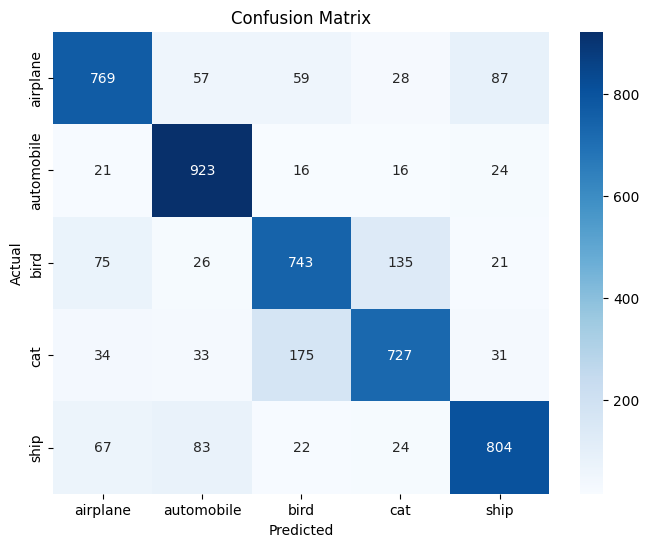

| Model         |   Accuracy |   Precision |   Recall |   F1-Score |   Inference Time (s/img) |   Param Count |
|:--------------|-----------:|------------:|---------:|-----------:|-------------------------:|--------------:|
| Classical CNN |     0.7932 |      0.7928 |   0.7932 |     0.7921 |                 0.000169 |       2191941 |


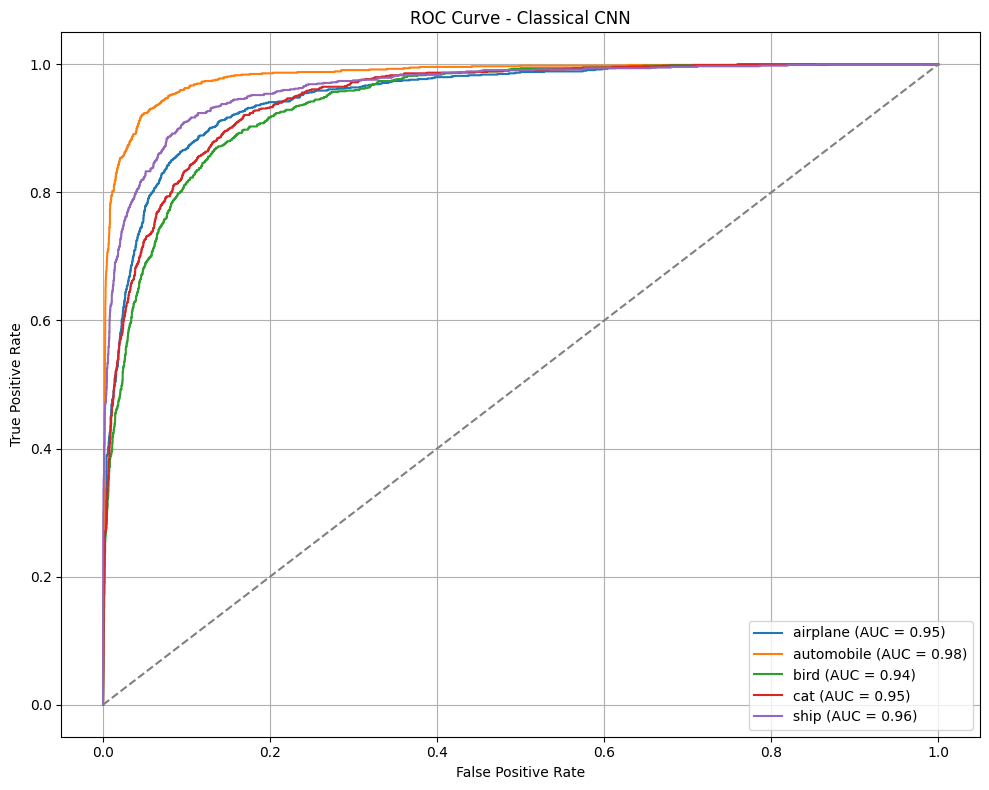



🚀 Testing Hybrid Quantum (8 Qubits)


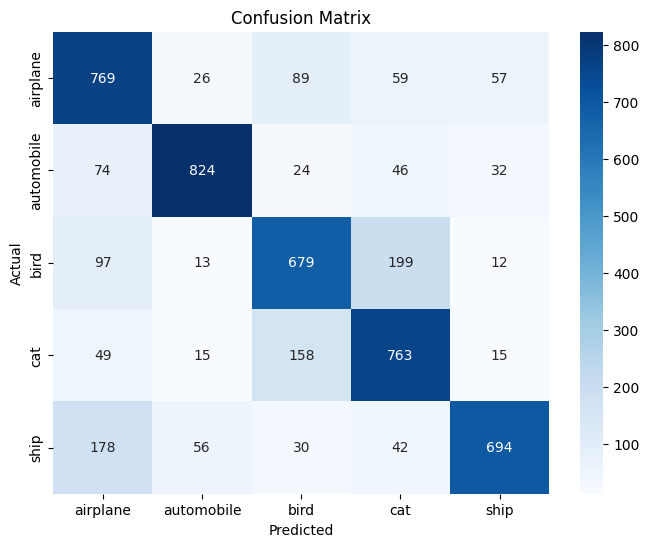

| Model                     |   Accuracy |   Precision |   Recall |   F1-Score |   Inference Time (s/img) |   Param Count |
|:--------------------------|-----------:|------------:|---------:|-----------:|-------------------------:|--------------:|
| Hybrid Quantum (8 Qubits) |     0.7458 |      0.7558 |   0.7458 |     0.7476 |                 0.001791 |        137541 |


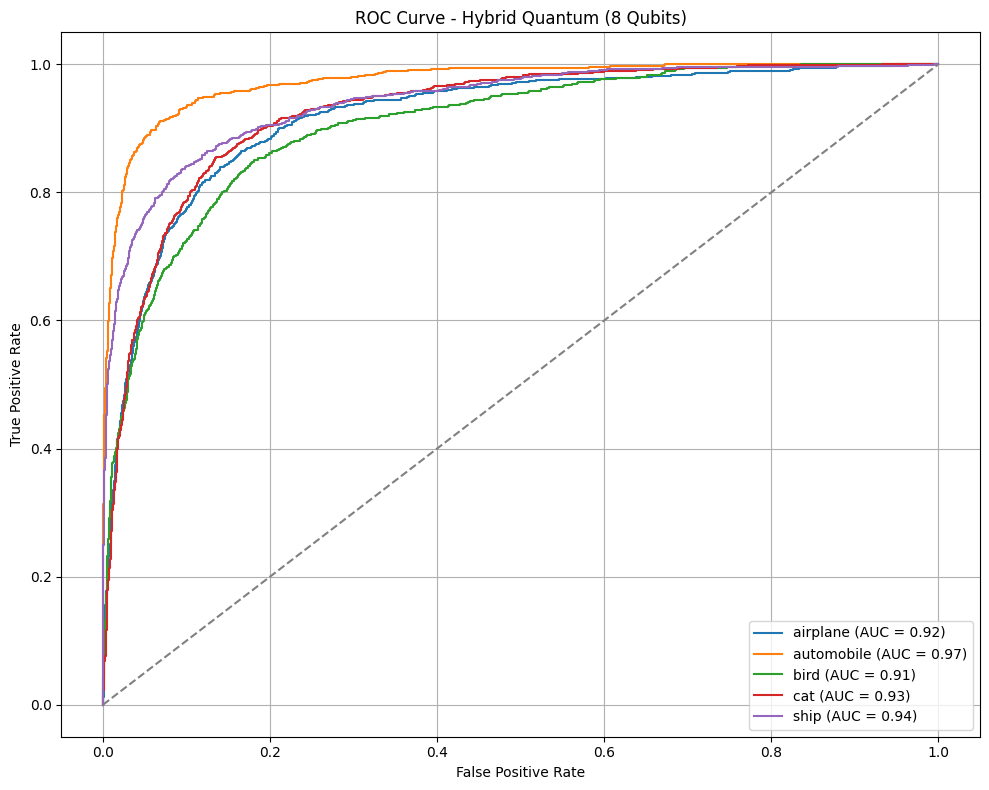



🚀 Testing Hybrid Quantum (12 Qubits)


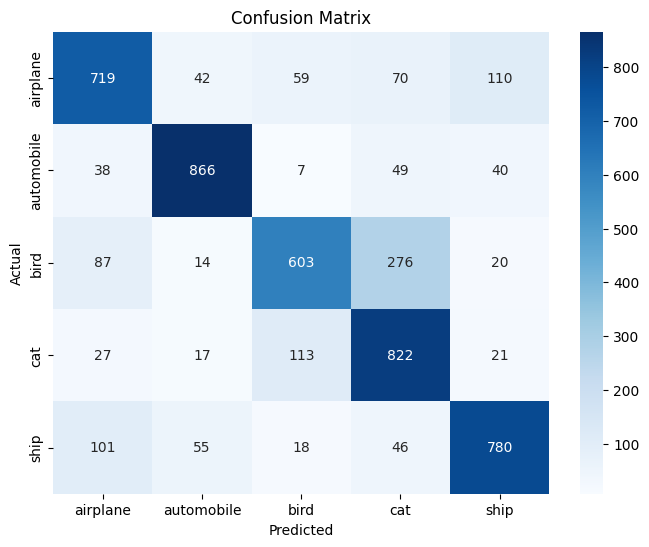

| Model                      |   Accuracy |   Precision |   Recall |   F1-Score |   Inference Time (s/img) |   Param Count |
|:---------------------------|-----------:|------------:|---------:|-----------:|-------------------------:|--------------:|
| Hybrid Quantum (12 Qubits) |      0.758 |      0.7638 |    0.758 |     0.7572 |                 0.002881 |        138149 |


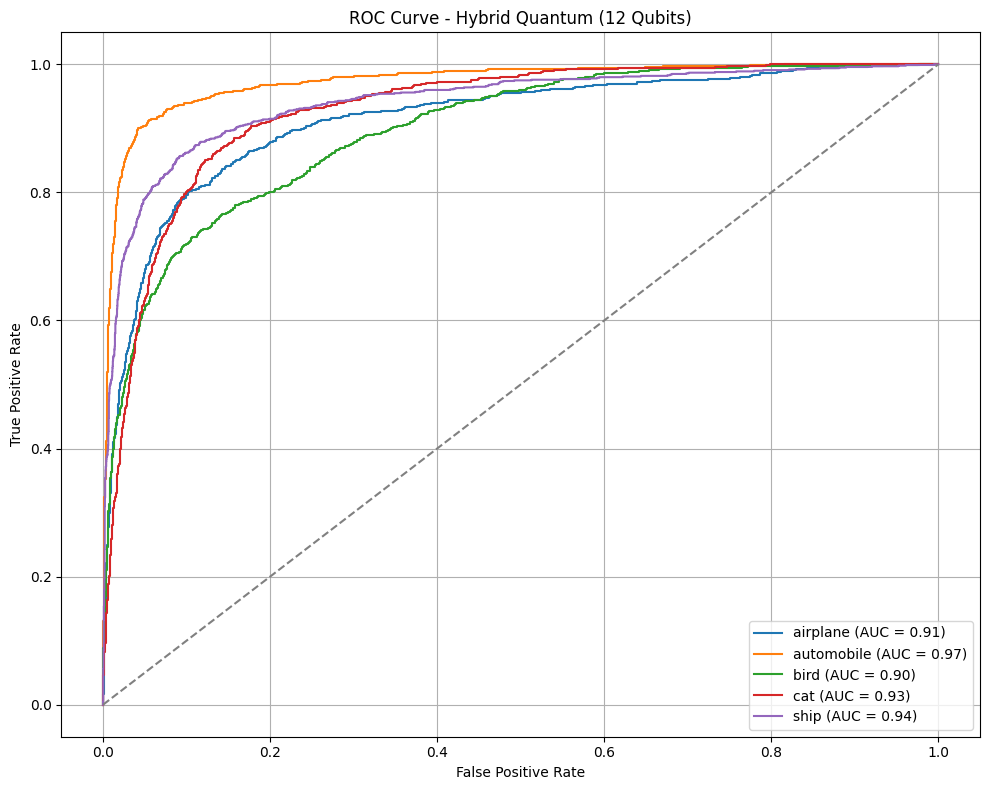

In [19]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    train_loader, val_loader, test_loader, class_names = get_loaders()
    model_paths = {
        "Hybrid Quantum (8 Qubits)": "/kaggle/working/saved_models/hybrid_quantum_8_qubits.pth",
        "Hybrid Quantum (12 Qubits)": "/kaggle/working/saved_models/hybrid_quantum_12_qubits.pth",
        "Classical CNN": "/kaggle/working/saved_models/classical_cnn.pth"
    }

    models = {
        "Classical CNN": cnn_model,
        "Hybrid Quantum (8 Qubits)": qmodel_3,
        "Hybrid Quantum (12 Qubits)": qmodel_4
    }
    for name, model in models.items():
            print(f"\n\n🚀 Testing {name}")
            load_model_and_test(
                model,
                model_path=None,  # We're not loading from file
                device=device,
                test_loader=test_loader,
                class_names=class_names,
                model_name=name,
                plot_roc=True
            )